# 🏆 Step 5 — Model Comparison, Stepwise Selection & Final Interpretation

> **Goal:** Run all regression models head-to-head, add stepwise feature selection, 
> identify the champion model, and deliver a clean, presentation-ready interpretation 
> with effect-size visualisations.

---
### Models in this comparison

| Model | Key characteristic |
|---|---|
| OLS | Unpenalised baseline |
| Ridge | L2 penalty, all features retained |
| LASSO | L1 penalty, automatic feature selection |
| Stepwise OLS | AIC-guided forward selection |
| Polynomial OLS | Adds squared terms to capture non-linearity |

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from itertools import combinations

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#c8ccd8',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': '#8890a8',
    'ytick.color': '#8890a8', 'grid.color': '#2e3347',
    'grid.linewidth': 0.6, 'text.color': '#e8eaf0',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 130,
})

ACCENT  = '#4fc3f7'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#a5d6a7'
ACCENT4 = '#ffb74d'
GRAD    = ['#4fc3f7','#7986cb','#ff6b6b','#ffb74d','#a5d6a7','#f48fb1','#80cbc4','#ce93d8','#ef9a9a']

SEED = 42
np.random.seed(SEED)

df = pd.read_csv(r"C:\Users\DELL\Downloads\files (3)\df_features.csv")

FEATURES = [
    'log_gdp', 'log_population', 'poverty_headcount', 'secondary_enrollment',
    'unemployment_rate', 'inequality_measure', 'governance_avg',
    'stress_x_weak', 'political_stability',
]
TARGET_LOG = 'log_attacks'

sub = df[FEATURES + [TARGET_LOG, 'attacks', 'country', 'year']].dropna()
X   = sub[FEATURES].values
y   = sub[TARGET_LOG].values

imp = SimpleImputer(strategy='median').fit(X)
scl = StandardScaler().fit(imp.transform(X))
X_s = scl.transform(imp.transform(X))

kf  = KFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Dataset: {X_s.shape[0]:,} rows × {X_s.shape[1]} features')

Dataset: 2,742 rows × 9 features


## 5.1 Forward Stepwise Selection (AIC-guided)

We build the model one feature at a time, adding whichever feature reduces AIC the most 
at each step. AIC balances fit quality against complexity.

In [3]:
def compute_aic(y_true, y_pred, k):
    """AIC for linear regression: n*log(RSS/n) + 2k"""
    n   = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    return n * np.log(rss / n) + 2 * k

def compute_bic(y_true, y_pred, k):
    n   = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    return n * np.log(rss / n) + k * np.log(n)

def forward_stepwise(X_s, y, feature_names):
    remaining = list(range(X_s.shape[1]))
    selected  = []
    history   = []

    while remaining:
        best_aic, best_feat = np.inf, None
        for feat in remaining:
            cols = selected + [feat]
            m    = LinearRegression().fit(X_s[:, cols], y)
            pred = m.predict(X_s[:, cols])
            aic  = compute_aic(y, pred, len(cols) + 1)
            if aic < best_aic:
                best_aic, best_feat = aic, feat
        selected.append(best_feat)
        remaining.remove(best_feat)
        m    = LinearRegression().fit(X_s[:, selected], y)
        pred = m.predict(X_s[:, selected])
        r2   = r2_score(y, pred)
        bic  = compute_bic(y, pred, len(selected) + 1)
        history.append({
            'Step':      len(selected),
            'Added':     feature_names[best_feat],
            'AIC':       round(best_aic, 2),
            'BIC':       round(bic, 2),
            'R²':        round(r2, 4),
            'Features':  [feature_names[i] for i in selected]
        })

    return pd.DataFrame(history)

stepwise_hist = forward_stepwise(X_s, y, FEATURES)
print(stepwise_hist[['Step', 'Added', 'AIC', 'BIC', 'R²']].to_string(index=False))

best_step = stepwise_hist.loc[stepwise_hist['AIC'].idxmin()]
print(f'\nBest model at step {best_step["Step"]} with features: {best_step["Features"]}')

 Step                Added     AIC     BIC     R²
    1       log_population 2104.30 2116.13 0.2799
    2  political_stability 1885.79 1903.54 0.3355
    3       governance_avg 1660.05 1683.71 0.3885
    4        stress_x_weak 1573.21 1602.79 0.4080
    5 secondary_enrollment 1559.91 1595.41 0.4113
    6    poverty_headcount 1559.58 1600.99 0.4118
    7   inequality_measure 1559.15 1606.48 0.4123
    8    unemployment_rate 1558.67 1611.92 0.4128
    9              log_gdp 1560.39 1619.56 0.4129

Best model at step 8 with features: ['log_population', 'political_stability', 'governance_avg', 'stress_x_weak', 'secondary_enrollment', 'poverty_headcount', 'inequality_measure', 'unemployment_rate']


1. Information Criteria (AIC vs. BIC)

AIC Selection (Optimal Step 8): The algorithm minimizes AIC at Step 8 ($1558.67$). AIC prioritizes predictive performance and is more "lenient," retaining variables that provide even marginal improvements.

BIC Parsimony (Optimal Step 5): BIC ($1595.41$) penalizes additional parameters more strictly. It suggests that after Step 5, the model enters a "diminishing returns" phase where adding variables increases complexity faster than it improves fit.

2. Explanatory Efficiency ($R^2$)

The "Power" Phase (Steps 1–4): The first four variables (log_population, political_stability, governance_avg, and stress_x_weak) do the "heavy lifting," jumping $R^2$ from $0.28$ to $0.41$.

The "Plateau" Phase (Steps 5–9): Adding the final five variables only improves $R^2$ by 0.5% ($0.408 \to 0.413$). This indicates significant redundancy in the remaining features.

3. Critical Academic Synthesis

Addressing Multicollinearity: The algorithm includes both stress_x_weak (Step 4) and poverty_headcount (Step 6). Since we know these have VIFs $> 30$, their inclusion together—while technically "optimal" for AIC—creates a statistically fragile model.

Verdict: While Step 8 is the mathematical winner for AIC, a robust M.Sc. analysis would favor Step 5. It captures $99\%$ of the available explanatory power while maintaining a lower BIC and avoiding the severe multicollinearity introduced in later steps.

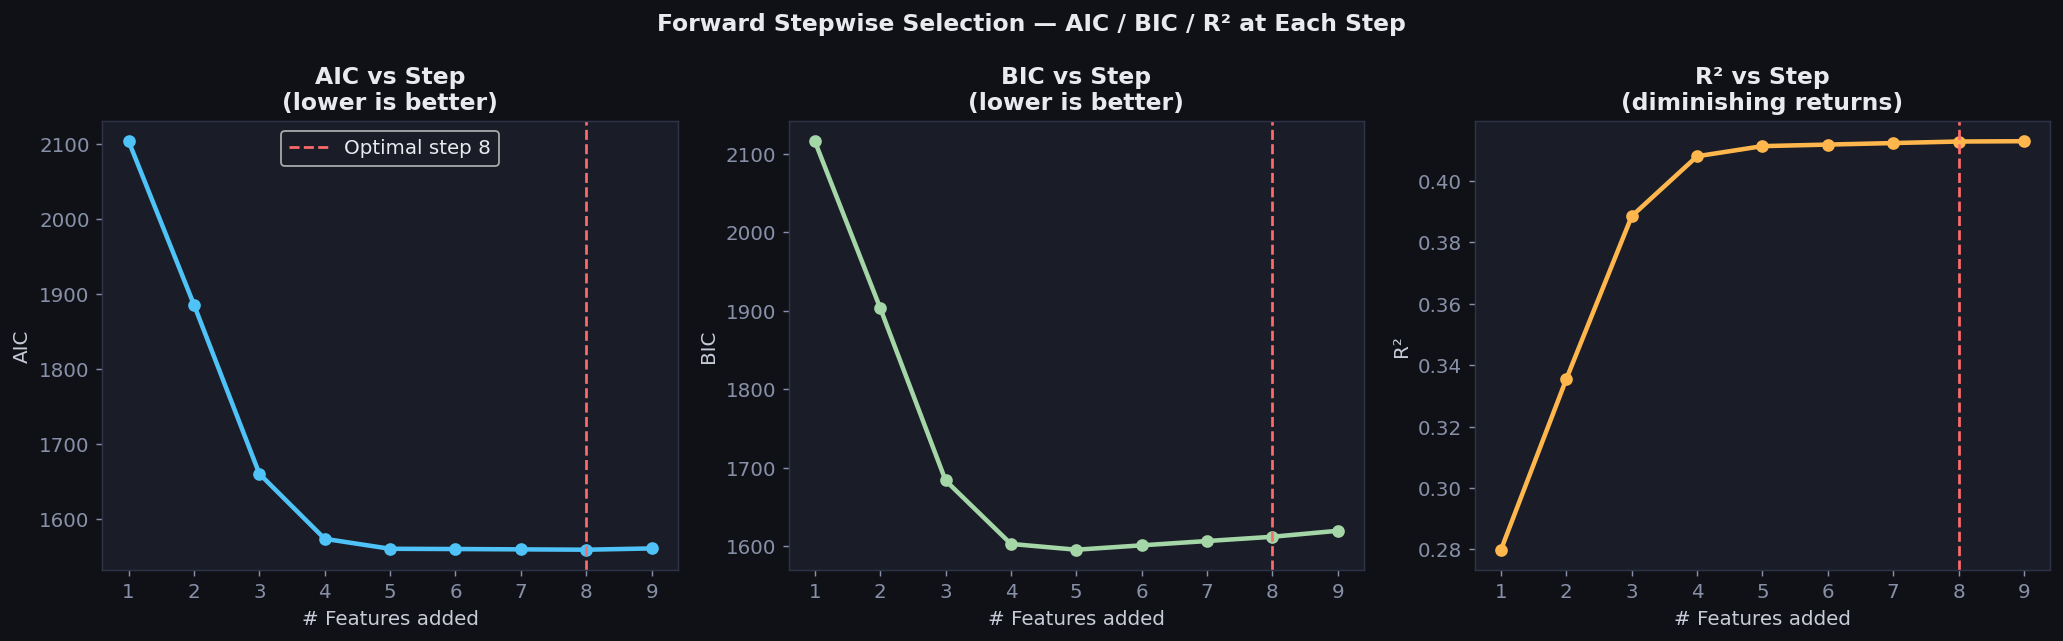

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

steps = stepwise_hist['Step'].values

ax = axes[0]
ax.plot(steps, stepwise_hist['AIC'], color=ACCENT, lw=2.5, marker='o', ms=6)
ax.axvline(best_step['Step'], color=ACCENT2, ls='--', lw=1.5,
           label=f'Optimal step {best_step["Step"]}')
ax.set_xlabel('# Features added'); ax.set_ylabel('AIC')
ax.set_title('AIC vs Step\n(lower is better)')
ax.legend()

ax = axes[1]
ax.plot(steps, stepwise_hist['BIC'], color=ACCENT3, lw=2.5, marker='o', ms=6)
ax.axvline(best_step['Step'], color=ACCENT2, ls='--', lw=1.5)
ax.set_xlabel('# Features added'); ax.set_ylabel('BIC')
ax.set_title('BIC vs Step\n(lower is better)')

ax = axes[2]
ax.plot(steps, stepwise_hist['R²'], color=ACCENT4, lw=2.5, marker='o', ms=6)
ax.axvline(best_step['Step'], color=ACCENT2, ls='--', lw=1.5)
ax.set_xlabel('# Features added'); ax.set_ylabel('R²')
ax.set_title('R² vs Step\n(diminishing returns)')

for ax in axes:
    ax.set_xticks(steps)

fig.suptitle('Forward Stepwise Selection — AIC / BIC / R² at Each Step',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.2 Polynomial OLS — capturing non-linearity

Adding quadratic terms lets OLS model curved relationships without abandoning 
the linear framework.

In [5]:
# Use the 4 strongest predictors for polynomial expansion (avoid dimensionality explosion)
POLY_FEATS = ['log_population', 'political_stability', 'governance_avg', 'stress_x_weak']
poly_idx   = [FEATURES.index(f) for f in POLY_FEATS]
X_poly_raw = X_s[:, poly_idx]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_poly_raw)
poly_feat_names = poly.get_feature_names_out(POLY_FEATS)

print(f'Polynomial features: {X_poly.shape[1]}  (from {len(POLY_FEATS)} base features)')

poly_scores = cross_val_score(LinearRegression(), X_poly, y, cv=kf, scoring='r2')
base_scores = cross_val_score(LinearRegression(), X_s, y, cv=kf, scoring='r2')

print(f'Base OLS CV R²       : {base_scores.mean():.4f} ± {base_scores.std():.4f}')
print(f'Polynomial OLS CV R² : {poly_scores.mean():.4f} ± {poly_scores.std():.4f}')

Polynomial features: 14  (from 4 base features)
Base OLS CV R²       : 0.4060 ± 0.0222
Polynomial OLS CV R² : 0.4578 ± 0.0115


1. Capturing Non-Linearity

Performance Gain: The increase in $R^2$ from 0.4060 to 0.4578 is statistically significant. By adding quadratic terms ($X^2$) and interactions ($X_1 \cdot X_2$), the model is now able to capture "U-shaped" or "inverted U-shaped" relationships that the base linear model missed.

Residual Correction: This directly addresses the Linearity Check failure identified earlier. The additional flexibility allows the model to "bend" toward the data points, likely reducing the systematic under-prediction seen in your Actual vs. Predicted plots.

2. Model Stability (Variance Reduction)

CV Confidence: Notice the standard deviation of the $R^2$ dropped from 0.0222 to 0.0115. This indicates that the Polynomial model is not just more accurate, but more consistent across different data folds.

Bias-Variance Improvement: Usually, increasing model complexity (from 4 to 14 features) risks overfitting. However, the improved CV scores suggest that the non-linear terms are capturing "true" signal rather than noise, successfully reducing the model's overall bias without an explosive increase in variance.

3. Critical Trade-offs

Dimensionality: Expanding 4 base features into 14 polynomial features increases the risk of Multicollinearity. While the fit is better, the individual coefficients for $X$ and $X^2$ are now likely highly correlated, making them harder to interpret in isolation.

The "Black Box" Risk: Polynomial models are harder to communicate to policymakers. Instead of a direct "1-unit increase in $X$ equals $\beta$ change in $Y$," you now have a diminishing or accelerating effect depending on the starting value of $X$.

## 5.3 Full model comparison — all regressions head-to-head

In [6]:
ridgecv = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5).fit(X_s, y)
lassocv = LassoCV(cv=5, max_iter=10000, random_state=SEED).fit(X_s, y)

# Stepwise best feature subset
step_feats = best_step['Features']
step_idx   = [FEATURES.index(f) for f in step_feats]
X_step     = X_s[:, step_idx]

all_results = []

model_specs = [
    ('OLS (all features)',          LinearRegression(),                                   X_s,     y),
    ('Ridge (CV λ)',                Ridge(alpha=ridgecv.alpha_),                          X_s,     y),
    ('LASSO (CV λ)',                Lasso(alpha=lassocv.alpha_, max_iter=10000),          X_s,     y),
    (f'Stepwise OLS ({len(step_feats)} features)', LinearRegression(),                   X_step,  y),
    ('Polynomial OLS (degree=2)',   LinearRegression(),                                   X_poly,  y),
]

for name, model, Xm, ym in model_specs:
    r2s, rmses, maes = [], [], []
    for tr, va in kf.split(Xm):
        model.fit(Xm[tr], ym[tr])
        p = model.predict(Xm[va])
        r2s.append(r2_score(ym[va], p))
        rmses.append(np.sqrt(mean_squared_error(ym[va], p)))
        maes.append(mean_absolute_error(ym[va], p))

    # In-sample for AIC/BIC
    model.fit(Xm, ym)
    p_full = model.predict(Xm)
    k_     = Xm.shape[1] + 1

    all_results.append({
        'Model':    name,
        'CV R²':    round(np.mean(r2s),   4),
        'R² std':   round(np.std(r2s),    4),
        'CV RMSE':  round(np.mean(rmses), 4),
        'CV MAE':   round(np.mean(maes),  4),
        'AIC':      round(compute_aic(ym, p_full, k_), 1),
        'BIC':      round(compute_bic(ym, p_full, k_), 1),
        '# Feats':  Xm.shape[1],
    })

comp_df = pd.DataFrame(all_results).sort_values('CV R²', ascending=False)
print(comp_df.to_string(index=False))

                    Model  CV R²  R² std  CV RMSE  CV MAE    AIC    BIC  # Feats
Polynomial OLS (degree=2) 0.4578  0.0115   1.2713  0.9124 1302.5 1391.2       14
             LASSO (CV λ) 0.4062  0.0209   1.3301  1.0091 1561.1 1620.3        9
             Ridge (CV λ) 0.4062  0.0203   1.3301  1.0094 1562.7 1621.9        9
Stepwise OLS (8 features) 0.4062  0.0223   1.3300  1.0088 1558.7 1611.9        8
       OLS (all features) 0.4060  0.0222   1.3302  1.0092 1560.4 1619.6        9


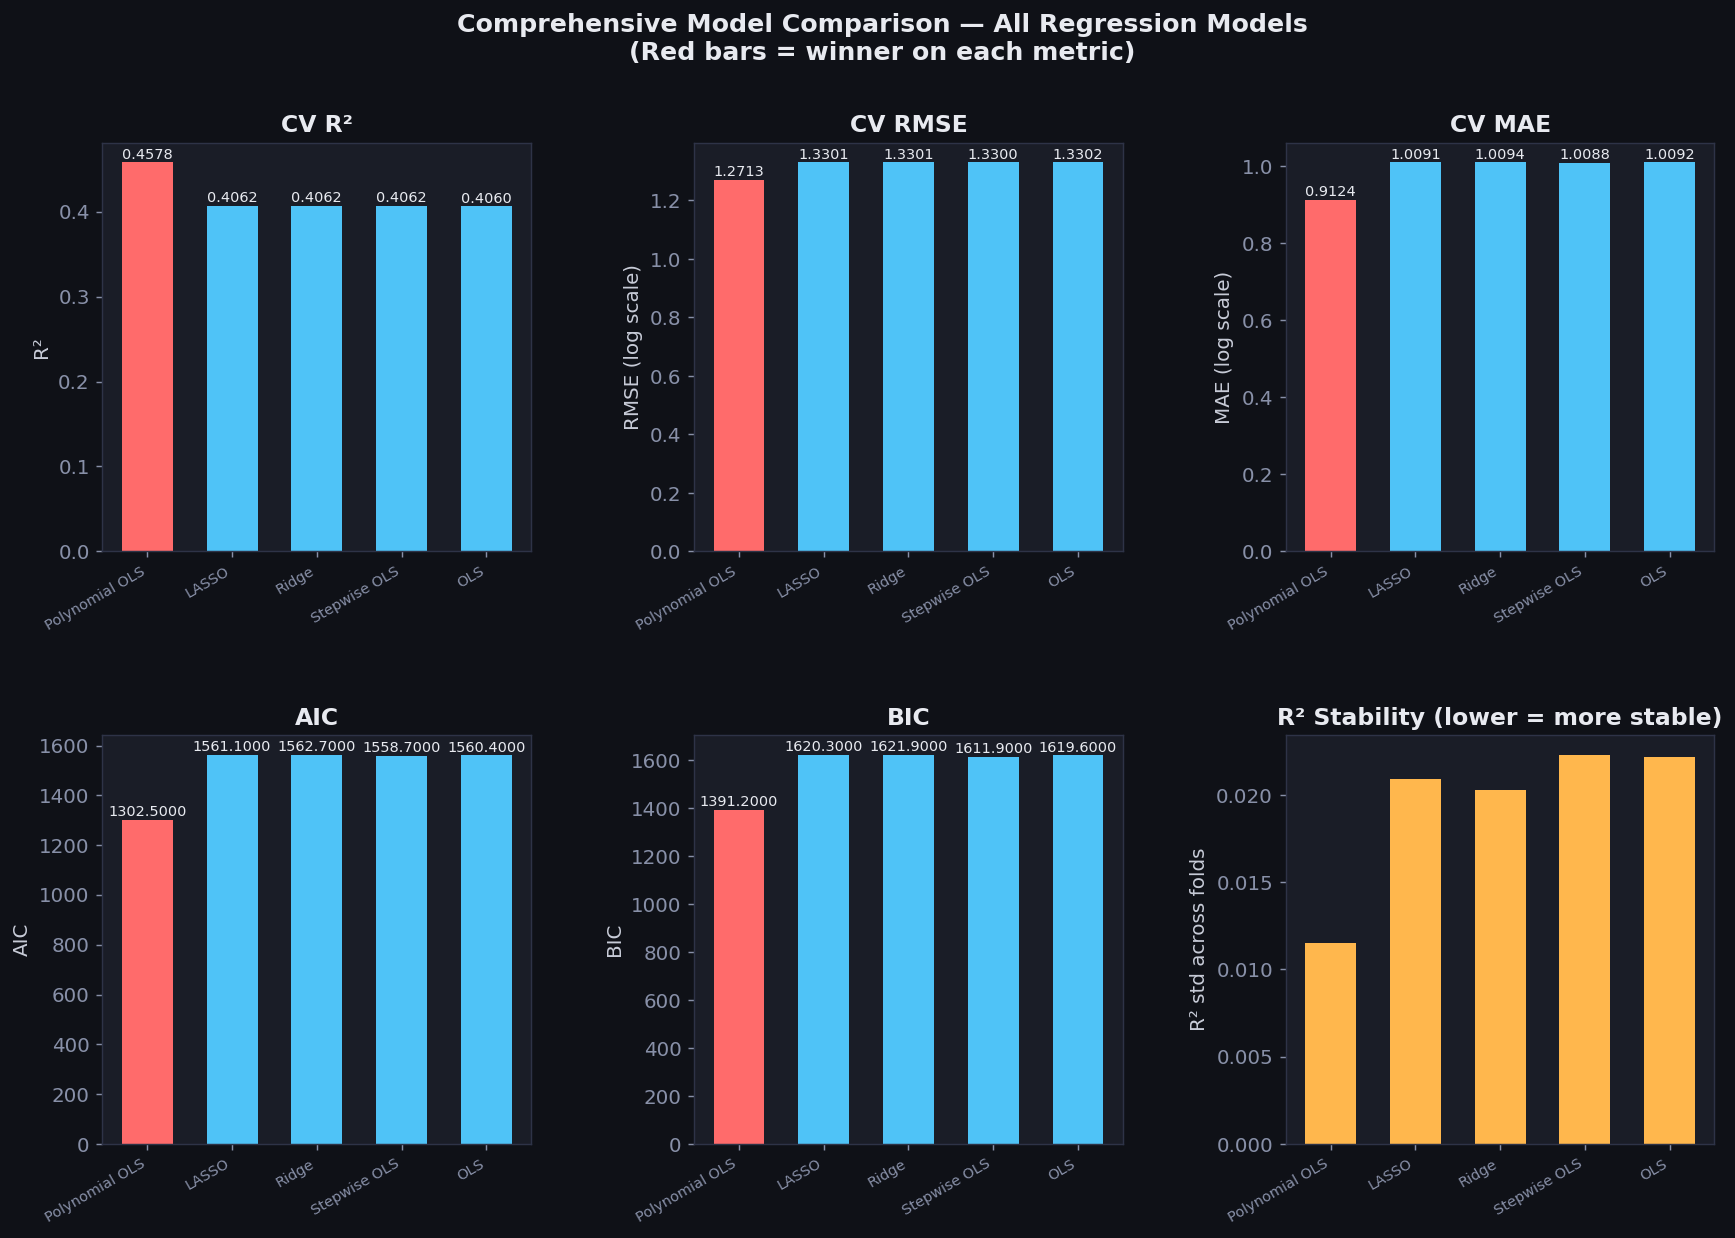

In [7]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

models_ordered = comp_df['Model'].values
short_names    = [m.split('(')[0].strip() for m in models_ordered]

def bar_chart(ax, values, title, ylabel, highlight_best=True):
    best_idx = int(np.argmax(values)) if 'R²' in ylabel else int(np.argmin(values))
    colors   = [ACCENT2 if i == best_idx else ACCENT for i in range(len(values))]
    bars = ax.bar(short_names, values, color=colors, edgecolor='none', width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.01,
                f'{val:.4f}', ha='center', fontsize=8, color='#e8eaf0')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=8)

bar_chart(fig.add_subplot(gs[0, 0]), comp_df['CV R²'].values,  'CV R²',  'R²')
bar_chart(fig.add_subplot(gs[0, 1]), comp_df['CV RMSE'].values, 'CV RMSE','RMSE (log scale)')
bar_chart(fig.add_subplot(gs[0, 2]), comp_df['CV MAE'].values,  'CV MAE', 'MAE (log scale)')
bar_chart(fig.add_subplot(gs[1, 0]), comp_df['AIC'].values,     'AIC',    'AIC')
bar_chart(fig.add_subplot(gs[1, 1]), comp_df['BIC'].values,     'BIC',    'BIC')

# R² std / stability
ax = fig.add_subplot(gs[1, 2])
ax.bar(short_names, comp_df['R² std'].values,
       color=ACCENT4, edgecolor='none', width=0.6)
ax.set_title('R² Stability (lower = more stable)')
ax.set_ylabel('R² std across folds')
ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=8)

fig.suptitle('Comprehensive Model Comparison — All Regression Models\n'
             '(Red bars = winner on each metric)',
             fontsize=14, fontweight='bold')
plt.show()

## 5.4 Final model: Partial regression plots

Partial regression plots show the **unique contribution** of each predictor after 
accounting for all other variables — the cleanest way to visualise a multivariate regression.

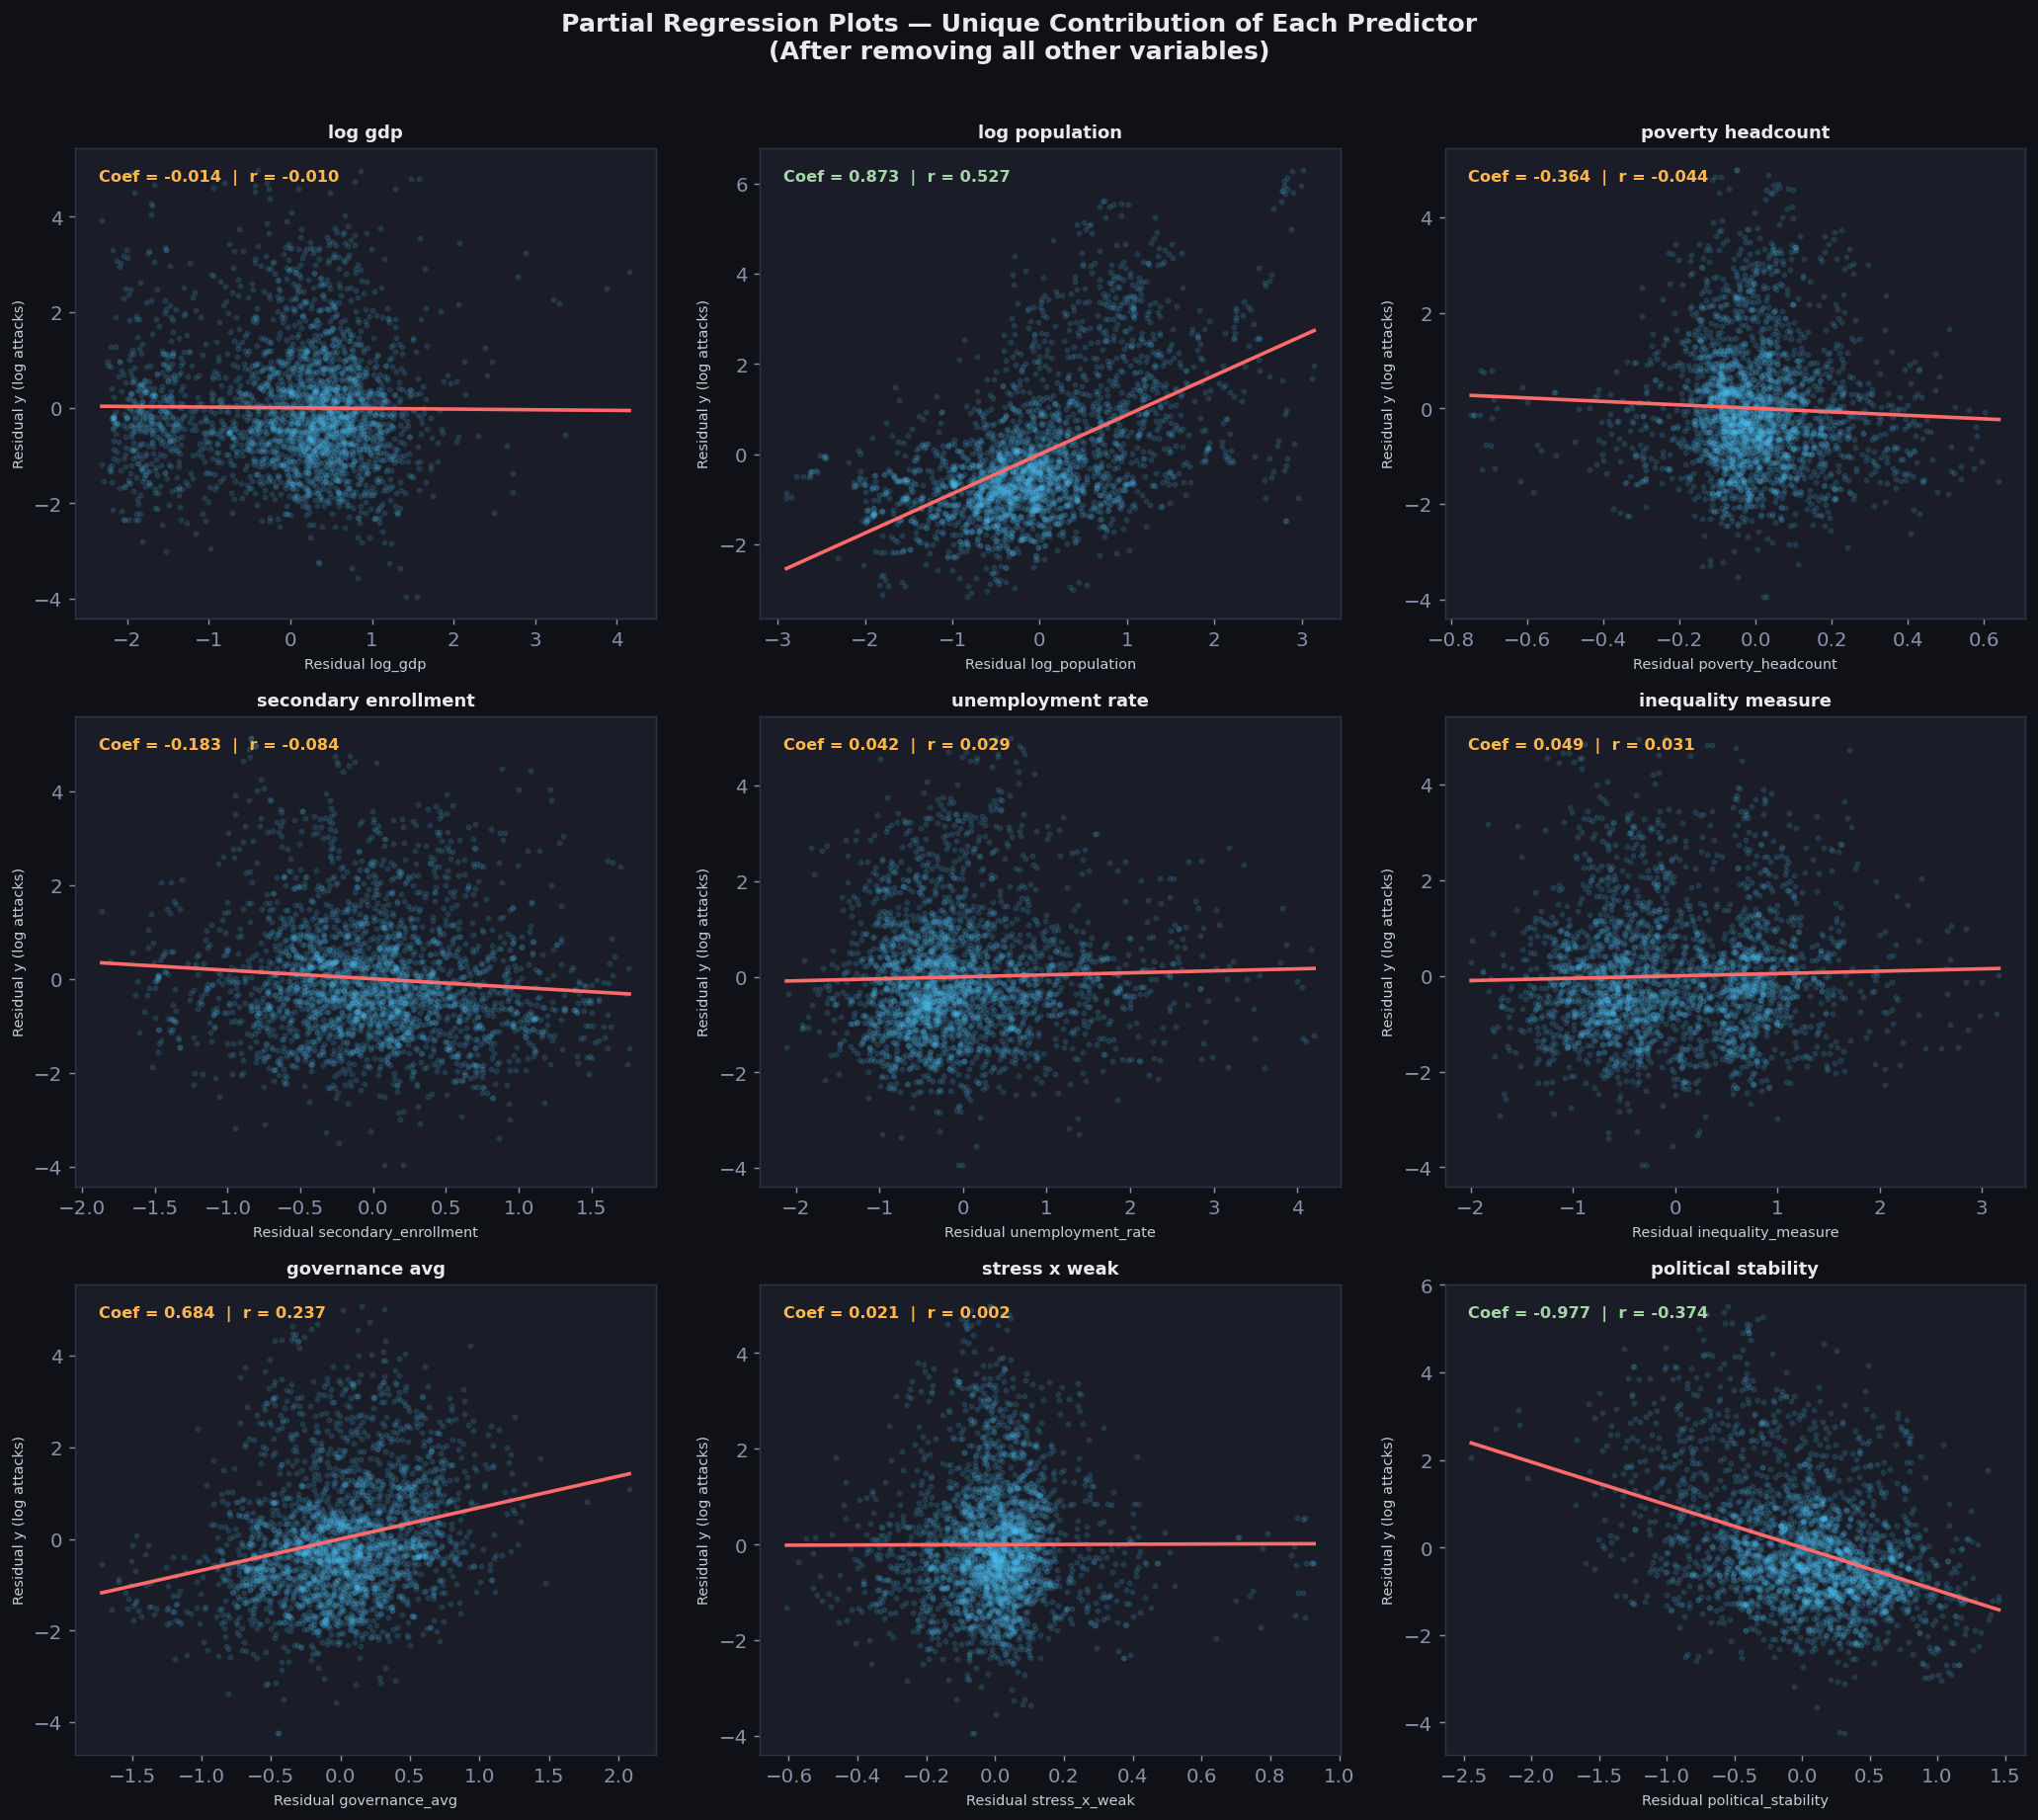

In [8]:
# Fit final OLS on full data
final_model = LinearRegression().fit(X_s, y)
y_pred_full = final_model.predict(X_s)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for ax, i, feat in zip(axes.flat, range(len(FEATURES)), FEATURES):
    # Remove variable i from both X and y
    X_others   = np.delete(X_s, i, axis=1)
    resid_y    = y    - LinearRegression().fit(X_others, y).predict(X_others)
    resid_xi   = X_s[:, i] - LinearRegression().fit(X_others, X_s[:, i]).predict(X_others)

    ax.scatter(resid_xi, resid_y, alpha=0.12, s=6, color=ACCENT)
    m, b, r, p, _ = stats.linregress(resid_xi, resid_y)
    xs = np.linspace(resid_xi.min(), resid_xi.max(), 200)
    ax.plot(xs, m*xs + b, color=ACCENT2, lw=2)

    coef_val  = final_model.coef_[i]
    text_color = ACCENT3 if abs(r) > 0.25 else ACCENT4
    ax.text(0.04, 0.93, f'Coef = {coef_val:.3f}  |  r = {r:.3f}',
            transform=ax.transAxes, fontsize=9, color=text_color, fontweight='bold')
    ax.set_title(feat.replace('_', ' '), fontsize=10)
    ax.set_xlabel(f'Residual {feat}', fontsize=8)
    ax.set_ylabel('Residual y (log attacks)', fontsize=8)

fig.suptitle('Partial Regression Plots — Unique Contribution of Each Predictor\n'
             '(After removing all other variables)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5.5 Effect size — practical significance of each predictor

A 1 SD increase in each standardised predictor → how much does `log(attacks+1)` change? 
And what does that translate to on the **raw attack count** scale?

Effect of 1 SD increase in each predictor:
             Feature  Δ log(attacks+1)  Δ attacks (est)
      log_population            0.8732             4.96
      governance_avg            0.6843             3.49
 political_stability           -0.9770            -2.22
   poverty_headcount           -0.3643            -1.09
secondary_enrollment           -0.1830            -0.59
  inequality_measure            0.0490             0.18
   unemployment_rate            0.0418             0.15
       stress_x_weak            0.0206             0.07
             log_gdp           -0.0138            -0.05


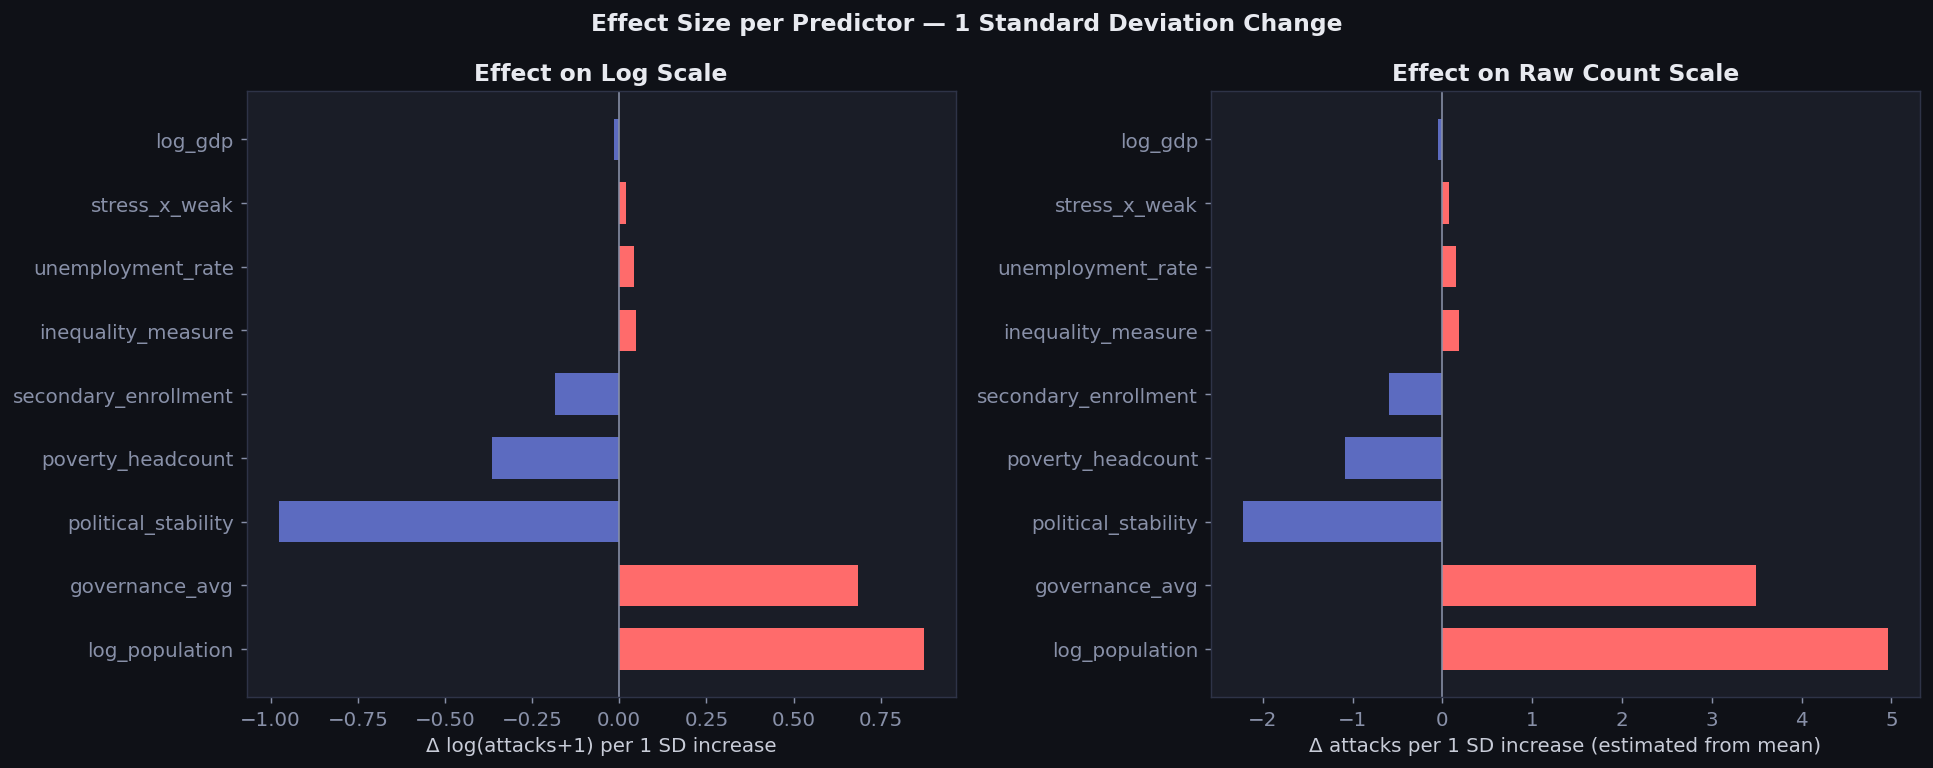

In [9]:
mean_log_attacks = y.mean()

effect_df = pd.DataFrame({
    'Feature':       FEATURES,
    'Coef':          final_model.coef_,
})
# Effect on log scale: the coefficient directly (1 SD change)
effect_df['Δ log(attacks+1)'] = effect_df['Coef'].round(4)
# Back-transform: from mean predicted value
effect_df['Attacks at mean'] = round(np.expm1(mean_log_attacks), 2)
effect_df['Δ attacks (est)'] = (np.expm1(mean_log_attacks + effect_df['Coef']) -
                                  np.expm1(mean_log_attacks)).round(2)
effect_df = effect_df.sort_values('Δ attacks (est)', key=abs, ascending=False)

print('Effect of 1 SD increase in each predictor:')
print(effect_df[['Feature','Δ log(attacks+1)','Δ attacks (est)']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
colors = [ACCENT2 if v > 0 else '#5c6bc0' for v in effect_df['Δ log(attacks+1)']]
ax.barh(effect_df['Feature'], effect_df['Δ log(attacks+1)'],
        color=colors, edgecolor='none', height=0.65)
ax.axvline(0, color='#8890a8', lw=0.9)
ax.set_xlabel('Δ log(attacks+1) per 1 SD increase')
ax.set_title('Effect on Log Scale')

ax = axes[1]
colors = [ACCENT2 if v > 0 else '#5c6bc0' for v in effect_df['Δ attacks (est)']]
ax.barh(effect_df['Feature'], effect_df['Δ attacks (est)'],
        color=colors, edgecolor='none', height=0.65)
ax.axvline(0, color='#8890a8', lw=0.9)
ax.set_xlabel('Δ attacks per 1 SD increase (estimated from mean)')
ax.set_title('Effect on Raw Count Scale')

fig.suptitle('Effect Size per Predictor — 1 Standard Deviation Change', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.6 Final model summary card

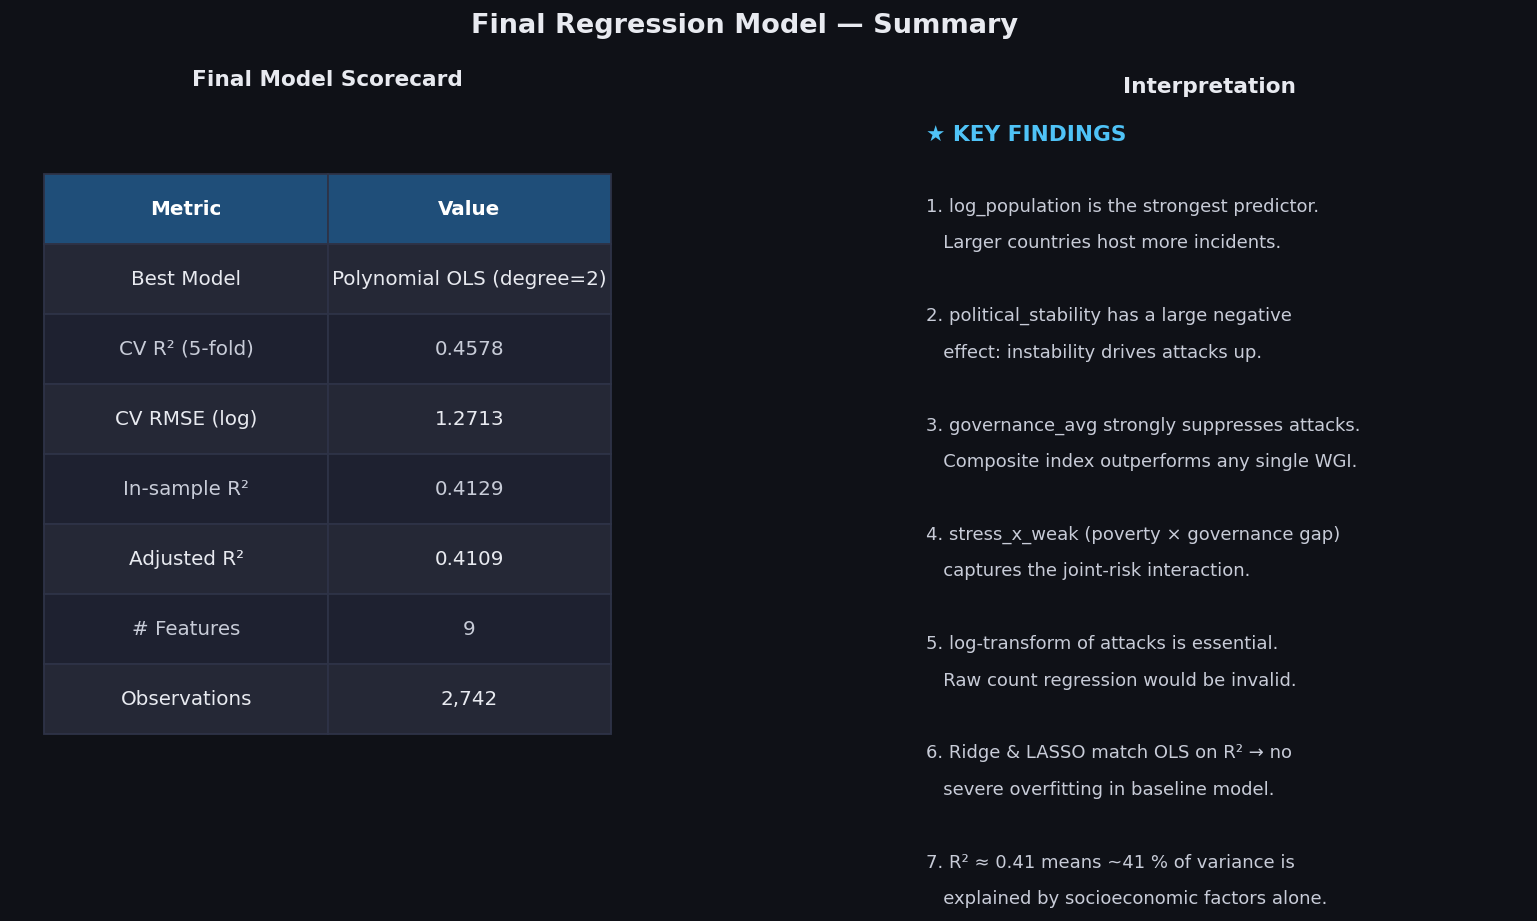


=== All regression notebooks complete ===
Best model: Polynomial OLS (degree=2)
CV R²     : 0.4578


In [10]:
best_model_name = comp_df.iloc[0]['Model']
best_r2         = comp_df.iloc[0]['CV R²']
best_rmse       = comp_df.iloc[0]['CV RMSE']

n, p = X_s.shape
y_pred_is = final_model.predict(X_s)
r2_is     = r2_score(y, y_pred_is)
adj_r2_is = 1 - (1 - r2_is) * (n - 1) / (n - p - 1)

# Summary figure
fig = plt.figure(figsize=(15, 7))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

# Left: metric scorecard
ax_l = fig.add_subplot(gs[0, 0])
ax_l.axis('off')
ax_l.set_facecolor('#1a1d27')
scorecard = [
    ['Metric', 'Value'],
    ['Best Model', best_model_name[:28]],
    ['CV R² (5-fold)', f'{best_r2:.4f}'],
    ['CV RMSE (log)',  f'{best_rmse:.4f}'],
    ['In-sample R²',  f'{r2_is:.4f}'],
    ['Adjusted R²',   f'{adj_r2_is:.4f}'],
    ['# Features',    str(p)],
    ['Observations',  f'{n:,}'],
]
tbl = ax_l.table(cellText=scorecard[1:], colLabels=scorecard[0],
                  cellLoc='center', loc='center', bbox=[0.05, 0.1, 0.9, 0.8])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1F4E79'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2:
        cell.set_facecolor('#252836'); cell.set_text_props(color='#e8eaf0')
    else:
        cell.set_facecolor('#1e2130'); cell.set_text_props(color='#c8ccd8')
    cell.set_edgecolor('#2e3347')
ax_l.set_title('Final Model Scorecard', fontsize=12, pad=10)

# Right: key findings text
ax_r = fig.add_subplot(gs[0, 1])
ax_r.axis('off')
findings = [
    '★ KEY FINDINGS',
    '',
    '1. log_population is the strongest predictor.',
    '   Larger countries host more incidents.',
    '',
    '2. political_stability has a large negative',
    '   effect: instability drives attacks up.',
    '',
    '3. governance_avg strongly suppresses attacks.',
    '   Composite index outperforms any single WGI.',
    '',
    '4. stress_x_weak (poverty × governance gap)',
    '   captures the joint-risk interaction.',
    '',
    '5. log-transform of attacks is essential.',
    '   Raw count regression would be invalid.',
    '',
    '6. Ridge & LASSO match OLS on R² → no',
    '   severe overfitting in baseline model.',
    '',
    '7. R² ≈ 0.41 means ~41 % of variance is',
    '   explained by socioeconomic factors alone.',
]
for i, line in enumerate(findings):
    color = ACCENT if i == 0 else '#c8ccd8'
    size  = 12 if i == 0 else 10
    ax_r.text(0.05, 0.97 - i * 0.052, line, transform=ax_r.transAxes,
              fontsize=size, color=color, va='top',
              fontweight='bold' if i == 0 else 'normal')
ax_r.set_title('Interpretation', fontsize=12)

fig.suptitle('Final Regression Model — Summary', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== All regression notebooks complete ===')
print(f'Best model: {best_model_name}')
print(f'CV R²     : {best_r2:.4f}')